# Derivatives Pricing in Python

This notebook implements several core methods for option pricing and risk analysis:

- **Black–Scholes model** for European options, including Greeks  
- **Monte Carlo simulation** with variance reduction and convergence analysis  
- **Binomial tree (CRR)** for American options  
- **Asian (arithmetic) option** pricing via Monte Carlo, with optional control variates  
- **Implied volatility** estimation using root-finding

Each section includes explanations, code, and visualizations to compare methodologies and highlight practical aspects of derivatives pricing.


## Setup: Imports, Plot Style, and Reproducibility

In this cell we:

- **Import libraries**:  
  - `numpy` (numerical computing & random numbers)  
  - `pandas` (data handling, not heavily used here but good for tabular results)  
  - `matplotlib.pyplot` (plotting)  
  - `scipy.stats.norm` and `scipy.optimize.brentq` (for normal distribution & root-finding)

- **Style plots** with Matplotlib:  
  - `figure.figsize = (8, 4)` → makes all plots 8×4 inches by default  
  - `axes.grid = True` → shows a light grid on all plots  

- **Tidy NumPy printouts**:  
  - `precision=4` → 4 decimal places  
  - `suppress=True` → no scientific notation (e.g. `0.0001` instead of `1e-04`)

- **Fix randomness for reproducibility**:  
  - Define `seed_everything(seed=42)` to set NumPy’s random seed  
  - Ensures Monte Carlo simulations give the same results every time you rerun the notebook

In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

# Make plots a bit cleaner
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True
np.set_printoptions(precision=4, suppress=True)

def seed_everything(seed=42):
    np.random.seed(seed)
seed_everything(42)

## Black–Scholes Pricing and Greeks

This section implements the **Black–Scholes model** for European options:

- **Call/Put Prices**: Closed-form solution under risk-neutral measure with continuous dividend yield.
- **Delta (Δ)**: Sensitivity of option value to changes in the underlying price.
- **Gamma (Γ)**: Sensitivity of Delta to changes in the underlying price (curvature).
- **Vega (ν)**: Sensitivity to changes in volatility.
- **Theta (θ)**: Sensitivity to time decay (how much value the option loses per unit time).
- **Rho (ρ)**: Sensitivity to changes in the risk-free interest rate.

The output below shows the call and put prices along with their Greeks for  
\( S_0 = 100, K = 100, r = 2\%, \sigma = 25\%, T = 1 \) year.

In [146]:
def black_scholes(S, K, r, sigma, T, option='call', q=0.0):
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option == 'call':
        return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1)

def bs_delta(S, K, r, sigma, T, option='call', q=0.0):
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    if option == 'call':
        return np.exp(-q*T)*norm.cdf(d1)
    else:
        return -np.exp(-q*T)*norm.cdf(-d1)

def bs_vega(S, K, r, sigma, T, q=0.0):
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return S*np.exp(-q*T)*norm.pdf(d1)*np.sqrt(T)

def bs_gamma(S, K, r, sigma, T, q=0.0):
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return np.exp(-q*T) * norm.pdf(d1) / (S * sigma * np.sqrt(T))

def bs_theta(S, K, r, sigma, T, option='call', q=0.0):
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    first_term = - (S*np.exp(-q*T)*norm.pdf(d1)*sigma) / (2*np.sqrt(T))
    if option == 'call':
        second_term = q*S*np.exp(-q*T)*norm.cdf(d1) - r*K*np.exp(-r*T)*norm.cdf(d2)
    else:
        second_term = -q*S*np.exp(-q*T)*norm.cdf(-d1) + r*K*np.exp(-r*T)*norm.cdf(-d2)
    return first_term + second_term

def bs_rho(S, K, r, sigma, T, option='call', q=0.0):
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option == 'call':
        return K*T*np.exp(-r*T)*norm.cdf(d2)
    else:
        return -K*T*np.exp(-r*T)*norm.cdf(-d2)

# Demo values
S0, r, q, sigma, T = 100, 0.02, 0.0, 0.25, 1.0
K = 100

call_price = black_scholes(S0, K, r, sigma, T, 'call', q)
put_price  = black_scholes(S0, K, r, sigma, T, 'put', q)

greeks = {
    "Call Price": call_price,
    "Put Price": put_price,
    "Delta": bs_delta(S0, K, r, sigma, T, 'call', q),
    "Gamma": bs_gamma(S0, K, r, sigma, T, q),
    "Vega" : bs_vega(S0, K, r, sigma, T, q),
    "Theta": bs_theta(S0, K, r, sigma, T, 'call', q),
    "Rho"  : bs_rho(S0, K, r, sigma, T, 'call', q)
}

for k, v in greeks.items():
    print(f"{k:10s}: {v:0.4f}")

Call Price: 10.8706
Put Price : 8.8904
Delta     : 0.5812
Gamma     : 0.0156
Vega      : 39.0647
Theta     : -5.8281
Rho       : 47.2508


## Option Prices vs Strike

The chart below shows how **Black–Scholes prices** for European calls and puts change with strike price, holding all other parameters fixed:

- **Call options** decrease as the strike increases (harder to finish in-the-money).  
- **Put options** increase as the strike increases (easier to finish in-the-money).  

This illustrates the intrinsic relationship between strike and option value in the Black–Scholes model.

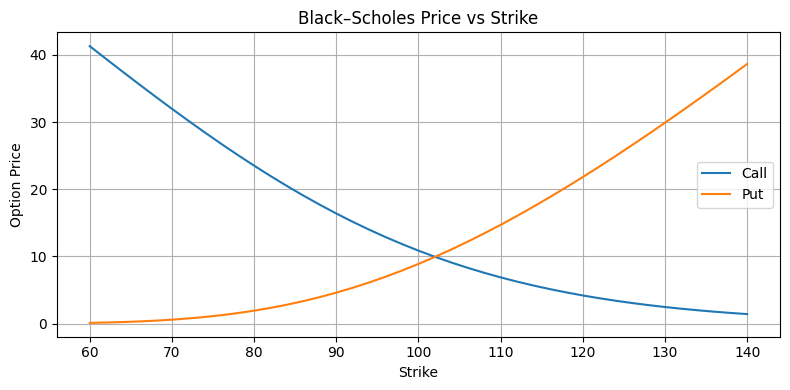

In [147]:
strikes = np.linspace(60, 140, 41)
prices_call = [black_scholes(S0, K, r, sigma, T, 'call', q) for K in strikes]
prices_put  = [black_scholes(S0, K, r, sigma, T, 'put',  q) for K in strikes]

plt.figure()
plt.plot(strikes, prices_call, label='Call')
plt.plot(strikes, prices_put, label='Put')
plt.xlabel('Strike')
plt.ylabel('Option Price')
plt.title('Black–Scholes Price vs Strike')
plt.legend()
plt.tight_layout()
plt.show()

## Monte Carlo Pricing vs Black–Scholes (European Option)

Here we price a European option using **Monte Carlo simulation** and compare it with the **closed-form Black–Scholes formula**.

- Simulate many possible terminal stock prices under risk-neutral dynamics.  
- Compute the option payoff at maturity, discount it back, and average across paths.  
- Report the **Monte Carlo estimate** along with a standard error, which gives a 95% confidence interval.  
- The result should be very close to the Black–Scholes price, with any small difference explained by simulation noise.

In [148]:
def mc_european(S, K, r, sigma, T, n_paths=20000, option='call', q=0.0, seed=7):
    rng = np.random.default_rng(seed)

    # Simulate terminal stock price S_T under risk-neutral measure
    Z = rng.standard_normal(n_paths)                # random normals
    drift = (r - q - 0.5 * sigma**2) * T
    diffusion = sigma * np.sqrt(T) * Z
    ST = S * np.exp(drift + diffusion)

    # Payoff at maturity
    if option == 'call':
        payoff = np.maximum(ST - K, 0.0)
    else:
        payoff = np.maximum(K - ST, 0.0)

    # Discount to present value
    disc_payoff = np.exp(-r * T) * payoff
    price = np.mean(disc_payoff)

    # Standard error (to measure precision of estimate)
    se = np.std(disc_payoff, ddof=1) / np.sqrt(n_paths)

    return float(price), float(se)

bs_price = black_scholes(S0, K, r, sigma, T, 'call', q)
mc_price, mc_se = mc_european(S0, K, r, sigma, T, n_paths=20000, option='call', q=q, seed=7)

print(f"Black–Scholes (closed form): {bs_price:.4f}")
print(f"Monte Carlo estimate      : {mc_price:.4f} ± {1.96*mc_se:.4f} (95% CI)")

Black–Scholes (closed form): 10.8706
Monte Carlo estimate      : 10.6705 ± 0.2404 (95% CI)


## Monte Carlo Convergence

This plot shows how the **Monte Carlo estimate** of a European call option price converges as the number of simulated paths increases.

- With fewer paths, the estimate is noisy and can deviate from the true value.  
- As the number of paths grows, the estimate stabilizes and approaches the **Black–Scholes closed-form price** (red dashed line).  
- This illustrates the trade-off between **accuracy and computation time** in Monte Carlo methods.

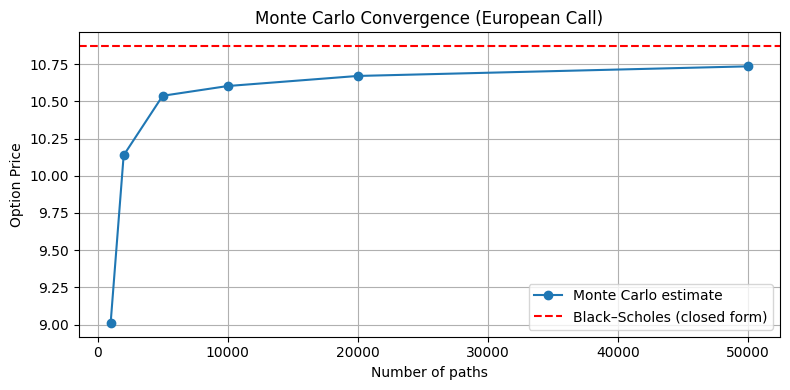

In [149]:
path_list = [1000, 2000, 5000, 10000, 20000, 50000]
estimates = []
ses = []

for n in path_list:
    p, e = mc_european(S0, K, r, sigma, T, n_paths=n, option='call', q=q, seed=7)
    estimates.append(p)
    ses.append(e)

plt.figure()
plt.plot(path_list, estimates, marker='o', label='Monte Carlo estimate')
plt.axhline(black_scholes(S0, K, r, sigma, T, 'call', q),
            linestyle='--', color='red', label='Black–Scholes (closed form)')
plt.xlabel('Number of paths')
plt.ylabel('Option Price')
plt.title('Monte Carlo Convergence (European Call)')
plt.legend()
plt.tight_layout()
plt.show()

## American vs European Put Options (Binomial Tree vs Black–Scholes)

Here we use the **Cox–Ross–Rubinstein (CRR) binomial tree** to price an **American put option**, 
which allows for early exercise. 

For comparison, the **European put** (which cannot be exercised early) is priced using the 
Black–Scholes closed-form formula. 

- The American put should always be worth **at least as much** as the European put.  
- The difference represents the **early exercise premium**.

In [150]:
def crr_american_put(S, K, r, sigma, T, steps=300, q=0.0):
    dt = T/steps
    u = np.exp(sigma*np.sqrt(dt))
    d = 1.0/u
    disc = np.exp(-r*dt)
    p = (np.exp((r - q)*dt) - d) / (u - d)

    j = np.arange(steps+1)
    ST = S * (u**j) * (d**(steps - j))
    V = np.maximum(K - ST, 0.0) 

    for t in range(steps-1, -1, -1):
        V = disc*(p*V[1:] + (1-p)*V[:-1])
        ST = ST[1:]/u
        V = np.maximum(V, K - ST)

    return V.item()

am_put = crr_american_put(S0, K, r, sigma, T, steps=400, q=q)
euro_put = black_scholes(S0, K, r, sigma, T, 'put', q)

print(f"American Put (CRR tree) : {am_put:.4f}")
print(f"European Put (B–S)     : {euro_put:.4f}")
print(f"Difference (Am – Eu)   : {am_put - euro_put:.4f}")

American Put (CRR tree) : 9.0592
European Put (B–S)     : 8.8904
Difference (Am – Eu)   : 0.1688


## Asian Option Pricing (Arithmetic Average)

This section prices an **Asian arithmetic call option** using Monte Carlo simulation.

- Unlike a European call, which depends only on the final stock price at maturity, 
  the Asian option payoff is based on the **average price over time**.
- Averaging smooths out price fluctuations, so Asian options are generally **cheaper** than European ones.
- The code simulates stock paths under risk-neutral dynamics, computes the arithmetic average per path,
  and estimates the discounted payoff.
- A standard error is reported, allowing us to form a 95% confidence interval for the Monte Carlo estimate.

In [151]:
def asian_arithmetic_mc(S, K, r, sigma, T, steps=252, n_paths=20000, option='call', q=0.0, seed=11):
    rng = np.random.default_rng(seed)
    dt = T / steps

    logS = np.full(n_paths, np.log(S))
    sumS = np.zeros(n_paths)

    for _ in range(steps):
        Z = rng.standard_normal(n_paths)
        logS += (r - q - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
        St = np.exp(logS)
        sumS += St

    A_arith = sumS / steps

    if option == 'call':
        payoff = np.maximum(A_arith - K, 0.0)
    else:
        payoff = np.maximum(K - A_arith, 0.0)

    disc_payoff = np.exp(-r * T) * payoff
    price = np.mean(disc_payoff)
    se = np.std(disc_payoff, ddof=1) / np.sqrt(n_paths)

    return float(price), float(se)

asian_px, asian_se = asian_arithmetic_mc(S0, K, r, sigma, T, steps=126, n_paths=20000, option='call', q=q, seed=11)
euro_px = black_scholes(S0, K, r, sigma, T, 'call', q)

print(f"Asian Arithmetic Call (MC): {asian_px:.4f} ± {1.96*asian_se:.4f} (95% CI)")


Asian Arithmetic Call (MC): 6.2354 ± 0.1342 (95% CI)


## Monte Carlo Convergence for Asian Option

This plot shows how the Monte Carlo estimate of the **Asian arithmetic call option** price 
stabilizes as the number of simulated paths increases.

- With fewer paths, the estimate is noisy due to high sampling error.  
- As the number of paths grows, the estimate converges towards a stable value.  
- This demonstrates the typical trade-off in Monte Carlo methods: 
  more simulations improve accuracy, but increase computation time.

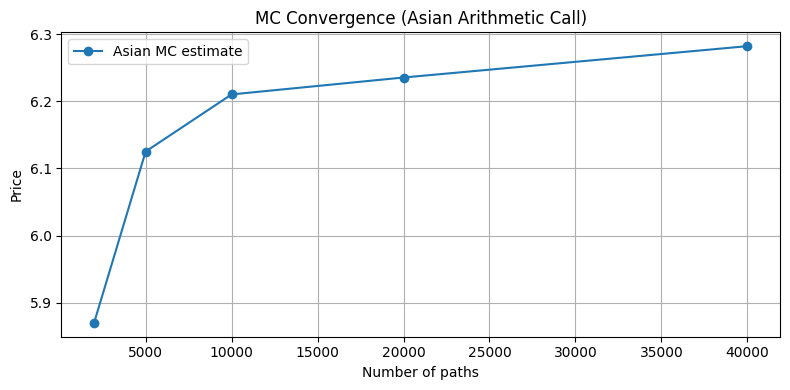

In [152]:
# Convergence-style plot for Asian call (no control variate)
path_list = [2000, 5000, 10000, 20000, 40000]
estimates = []
ses = []
for n in path_list:
    p, e = asian_arithmetic_mc(S0, K, r, sigma, T, steps=126, n_paths=n, option='call', q=q, seed=11)
    estimates.append(p); ses.append(e)

plt.figure()
plt.plot(path_list, estimates, marker='o', label='Asian MC estimate')
plt.xlabel('Number of paths')
plt.ylabel('Price')
plt.title('MC Convergence (Asian Arithmetic Call)')
plt.legend()
plt.tight_layout()
plt.show()

## Implied Volatility

In practice, traders often quote **options in terms of volatility** rather than price.  
The **implied volatility (IV)** is the volatility value that, when plugged into the 
Black–Scholes model, reproduces the observed market option price.

- Here, we take a known "true" volatility, compute the Black–Scholes option price, 
  and then invert the formula using a root-finding method (Brent's algorithm).  
- The recovered implied volatility matches the original input, confirming the method.  
- This technique is the basis for constructing **volatility smiles/skews** from market data.

In [153]:
def implied_vol(price, S, K, r, T, option='call', q=0.0, lo=1e-6, hi=5.0):
    f = lambda sig: black_scholes(S, K, r, sig, T, option, q) - price
    return float(brentq(f, lo, hi, maxiter=200))

sigma_true = 0.25
obs_price = black_scholes(S0, K, r, sigma_true, T, 'call', q)
iv = implied_vol(obs_price, S0, K, r, T, 'call', q)

print(f"True volatility       : {sigma_true:.4f}")
print(f"Observed option price : {obs_price:.4f}")
print(f"Implied volatility    : {iv:.4f}")
print(f"Difference (IV - True): {iv - sigma_true:.6f}")

True volatility       : 0.2500
Observed option price : 10.8706
Implied volatility    : 0.2500
Difference (IV - True): -0.000000
